In [1]:
import pandas as pd
import missingno
import sys

sys.path.insert(0, "../Modules")

from preprocessing_utils import *

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'

In [3]:
dataset = pd.read_csv(f'data/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2021.csv', encoding=enc)
geomorphological = pd.read_csv(f'data/{NUTS0}_{NUTS2}_Geomorphological_filled.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [4]:
dataset.head()

,x,y,dt_placement,nuts2,lau1,lau1_id,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,landcover_1990,landcover_2000,landcover_2006,landcover_2012,landcover_2018,mosq_pred,mosq_previous,case
0,22.77356,39.67760,2010-01-01,θεσσαλιας,αγιας,22,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,661.8,10705.0,17.3,45.74874,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.267143,16.284286,8.25,11.242240,5.302469,9.587946,4.419169,16.775915,6.090496,19.523378,8.155853,22.057143,52.814286,0.0,295.000000,295.000000,295.000000,295.000000,295.000000,55,0,0
1,22.69493,39.10844,2010-01-01,θεσσαλιας,αλμυρου,6,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,905.4,16004.0,20.6,45.21648,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.082222,16.254444,11.91,9.896909,4.265526,10.677746,3.618618,17.039068,5.650136,20.541023,7.613520,13.700000,31.211111,0.3,260.444444,260.444444,260.444444,260.444444,260.444444,41,0,0
2,23.91189,39.20320,2010-01-01,θεσσαλιας,αλοννησου,24,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,129.6,3153.0,21.2,45.92025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.640000,17.470000,11.81,12.687143,9.572857,11.814615,7.350000,14.911538,8.634000,17.832609,10.427500,62.200000,98.600000,0.0,323.000000,323.000000,323.000000,323.000000,323.000000,24,0,0
3,21.43052,39.25731,2010-01-01,θεσσαλιας,αργιθεας,0,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,372.9,3515.0,9.3,44.72587,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.565556,0.587778,5.773333,-1.428201,13.292222,2.807245,18.730554,6.231131,47.133333,88.466667,22.1,323.666667,323.666667,320.000000,320.000000,320.000000,94,0,0
4,22.93792,39.41186,2010-01-01,θεσσαλιας,βολου,14,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,385.6,138865.0,374.6,45.60091,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.356667,NaN,12.845119,5.105833,12.089515,3.862547,17.407709,6.368088,21.703833,8.805092,30.066667,48.733333,0.0,252.666667,252.666667,252.666667,252.666667,252.666667,34,0,0


In [5]:
geomorphological.head()

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,22.63715,39.66477,3052.548676,129.956226,2,166.574714,47.992932,180.349082,0.0,571.901338
1,22.70702,39.75460,11271.147713,3062.222244,32,133.272361,1087.057545,157.065722,0.0,4.139724
2,22.73031,39.79054,7228.976051,128.457199,7,143.757562,1236.817763,177.791748,0.0,56.070798
3,22.77688,39.66477,9517.677436,442.116743,6,215.239966,132.347263,181.430575,0.0,40.243238
4,22.77688,39.70070,8282.127022,1331.619869,1,123.585589,121.767859,183.036108,0.0,21.311709


In [6]:
distances, indicies = calculate_nearest_topological(dataset, geomorphological)

In [7]:
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 19.743606516388066


In [8]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

In [9]:
for index in indicies:
    df_geo = df_geo.append(geomorphological.iloc[[index]])

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

In [10]:
dataset = pd.concat([dataset, df_geo], axis=1, join = 'outer')

In [11]:
dataset.head()

,x,y,dt_placement,nuts2,lau1,lau1_id,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,landcover_1990,landcover_2000,landcover_2006,landcover_2012,landcover_2018,mosq_pred,mosq_previous,case,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,22.77356,39.67760,2010-01-01,θεσσαλιας,αγιας,22,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,661.8,10705.0,17.3,45.74874,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.267143,16.284286,8.25,11.242240,5.302469,9.587946,4.419169,16.775915,6.090496,19.523378,8.155853,22.057143,52.814286,0.0,295.000000,295.000000,295.000000,295.000000,295.000000,55,0,0,9517.677436,442.116743,6,215.239966,132.347263,181.430575,0.0,40.243238
1,22.69493,39.10844,2010-01-01,θεσσαλιας,αλμυρου,6,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,905.4,16004.0,20.6,45.21648,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.082222,16.254444,11.91,9.896909,4.265526,10.677746,3.618618,17.039068,5.650136,20.541023,7.613520,13.700000,31.211111,0.3,260.444444,260.444444,260.444444,260.444444,260.444444,41,0,0,10017.207897,1610.666116,14,259.585198,342.571837,171.163634,0.0,3.415750
2,23.91189,39.20320,2010-01-01,θεσσαλιας,αλοννησου,24,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,129.6,3153.0,21.2,45.92025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.640000,17.470000,11.81,12.687143,9.572857,11.814615,7.350000,14.911538,8.634000,17.832609,10.427500,62.200000,98.600000,0.0,323.000000,323.000000,323.000000,323.000000,323.000000,24,0,0,1484.683259,55302.082778,24,302.637680,165.397106,195.027810,0.0,1.676994
3,21.43052,39.25731,2010-01-01,θεσσαλιας,αργιθεας,0,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,372.9,3515.0,9.3,44.72587,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.565556,0.587778,5.773333,-1.428201,13.292222,2.807245,18.730554,6.231131,47.133333,88.466667,22.1,323.666667,323.666667,320.000000,320.000000,320.000000,94,0,0,19327.278832,1925.318354,27,284.268894,1127.254453,234.678996,0.0,1.719393
4,22.93792,39.41186,2010-01-01,θεσσαλιας,βολου,14,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,385.6,138865.0,374.6,45.60091,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.356667,NaN,12.845119,5.105833,12.089515,3.862547,17.407709,6.368088,21.703833,8.805092,30.066667,48.733333,0.0,252.666667,252.666667,252.666667,252.666667,252.666667,34,0,0,5935.142744,3071.988689,5,143.181190,234.931813,174.426021,0.0,4.643743


<AxesSubplot:>

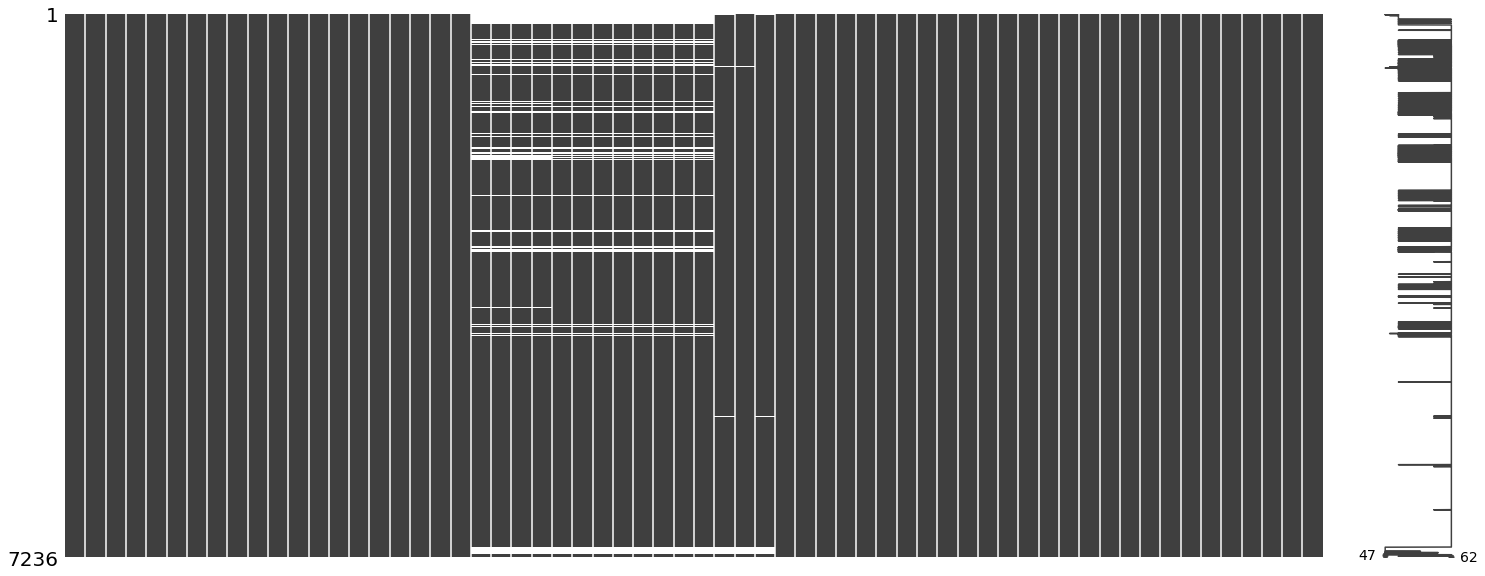

In [12]:
missingno.matrix(dataset)

In [13]:
cols = dataset.columns

In [14]:
cols

Index(['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'lau1_id', 'day', 'month',
       'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'week_sin', 'week_cos', 'area', 'population', 'population_density',
       'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_jan_day_mean',
       'lst_jan_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean',
       'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_apr_day_mean',
       'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'landcover_1990', 'landcover_2000',
       'landcover_2006', 'landcover_2012', 'landcover_2018', 'mosq_pred',
       'mosq_previous', 'case', 'distance_to_coast', 'distance_to_river',
       'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km',
       'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m'],
    

In [15]:
len(cols)

62

In [16]:
rearranged = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'lau1_id', 'day', 'month',
       'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'week_sin', 'week_cos', 'area', 'population', 'population_density',
       'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_jan_day_mean',
       'lst_jan_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean',
       'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_apr_day_mean',
       'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'landcover_1990', 'landcover_2000',
       'landcover_2006', 'landcover_2012', 'landcover_2018', 'mosq_pred', 'mosq_previous', 'case']

In [17]:
len(rearranged)

62

In [18]:
dataset = dataset[rearranged]

In [19]:
dataset.to_csv(f"data/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2021.csv", encoding = enc, index = False)